# Exploratory Data Analysis (EDA)

We load the cleaned dataset produced by `01_Data_Ingestion_Cleaning` and explore its structure, distributions, text characteristics and potential quality issues before moving to feature engineering and modeling.

In [11]:
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

In [12]:
# Loading the cleaned dataset produced by 01_Data_Ingestion_Cleaning
df = pd.read_csv("data/reviews_cleaned.csv")
print(f"Loaded {len(df):,} reviews")
df.head()

Loaded 325,305 reviews


,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase,product_title,brand,description_clean,product_avg_rating,product_rating_count,price,store
0,4,12 mg is 12 on the periodic table people! Mg f...,This review is more to clarify someone else's ...,NaN,B07TDSJZMR,B07TDSJZMR,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2020-02-06 00:49:35.902,3,True,High Potency Magnesium Citrate Capsules 1000mg...,Life Nutrition,NaN,4.5,470,NaN,Life Nutrition
1,5,Fantastic,I have been suffering a couple months with hee...,NaN,B07KJVGNN5,B07KJVGNN5,AHSPLDNW5OOUK2PLH7GXLACFBZNQ,2019-07-24 11:13:58.905,0,True,"Dr. Foot's Gel Heel Protectors, Plantar Fascii...",NaN,NaN,3.6,78,NaN,Dr.Foot
2,4,It holds the water and makes bubbles. That's w...,It's cheap and it does what I wanted. The mass...,NaN,B007HY7GC2,B092RP73CX,AEZGPLOYTSAPR3DHZKKXEFPAXUAA,2022-09-04 02:29:02.725,7,True,"Homedics Bubble Bliss Deluxe-Foot Spa, Heat Ma...",Homedics,NaN,4.4,8312,NaN,Homedics
3,1,Not for me,Didn't do a thing for me. Not saying they don'...,NaN,B08KYJLF5T,B08KYJLF5T,AEQAYV7RXZEBXMQIQPL6KCT2CFWQ,2022-01-20 23:53:07.262,0,True,Brain Supplement 1053mg - Premium Nootropic Br...,Nature's Nutrition,NaN,4.1,94,NaN,Nature's Nutrition
4,5,returned,it was a nice tray smaller than i expected but...,NaN,B01H0SVP9O,B01H0SVP9O,AHGAOIZVODNHYMNCBV4DECZH42UQ,2020-11-11 14:54:54.192,0,True,North American Walker Tray with Non-Slip Grip Mat,NaN,Walker tray with grip mat. Turn any walker int...,4.0,2072,26.9,North American Health + Wellness


In [13]:
# Remove duplicates before any analysis
n_before = len(df)
df = df.drop_duplicates(subset=["user_id", "parent_asin"])
df = df.drop_duplicates(subset=["text"])
print(f"Before dedup: {n_before:,} reviews")
print(f"After dedup:  {len(df):,} reviews ({n_before - len(df):,} removed)")

Before dedup: 325,305 reviews
After dedup:  298,526 reviews (26,779 removed)


## Corpus-Level Profiling

Basic shape, column types, missing values and sample size of the final merged dataset.

In [14]:
# Corpus size and column overview
print(f"Total reviews:                  {len(df):,}")
print(f"Unique products (parent_asin):  {df['parent_asin'].nunique():,}")
print(f"Unique reviewers (user_id):     {df['user_id'].nunique():,}")
print(f"Columns: {list(df.columns)}\n")

# Temporal coverage
df["timestamp"] = pd.to_datetime(df["timestamp"])
print(f"Period: {df['timestamp'].min().date()} → {df['timestamp'].max().date()}\n")

# Adding text length columns for analysis
df["char_len"] = df["text"].astype(str).str.len()
df["tok_len"]  = df["text"].astype(str).str.split().str.len()

# Summary table — more readable than raw describe()
summary = df[["char_len", "tok_len"]].agg(["mean", "median", "std", "min", "max"]).round(1)
summary.index.name = "stat"
print(summary)

Total reviews:                  298,526
Unique products (parent_asin):  7,658
Unique reviewers (user_id):     291,494
Columns: ['rating', 'title', 'text', 'images', 'asin', 'parent_asin', 'user_id', 'timestamp', 'helpful_vote', 'verified_purchase', 'product_title', 'brand', 'description_clean', 'product_avg_rating', 'product_rating_count', 'price', 'store']

Period: 2004-02-25 → 2023-09-11

        char_len  tok_len
stat                     
mean       177.1     33.7
median     111.0     21.0
std        228.3     43.4
min          1.0      1.0
max      16350.0   2783.0


## Rating & Text Length Distributions

We check how ratings are distributed and how long reviews are in characters and tokens.

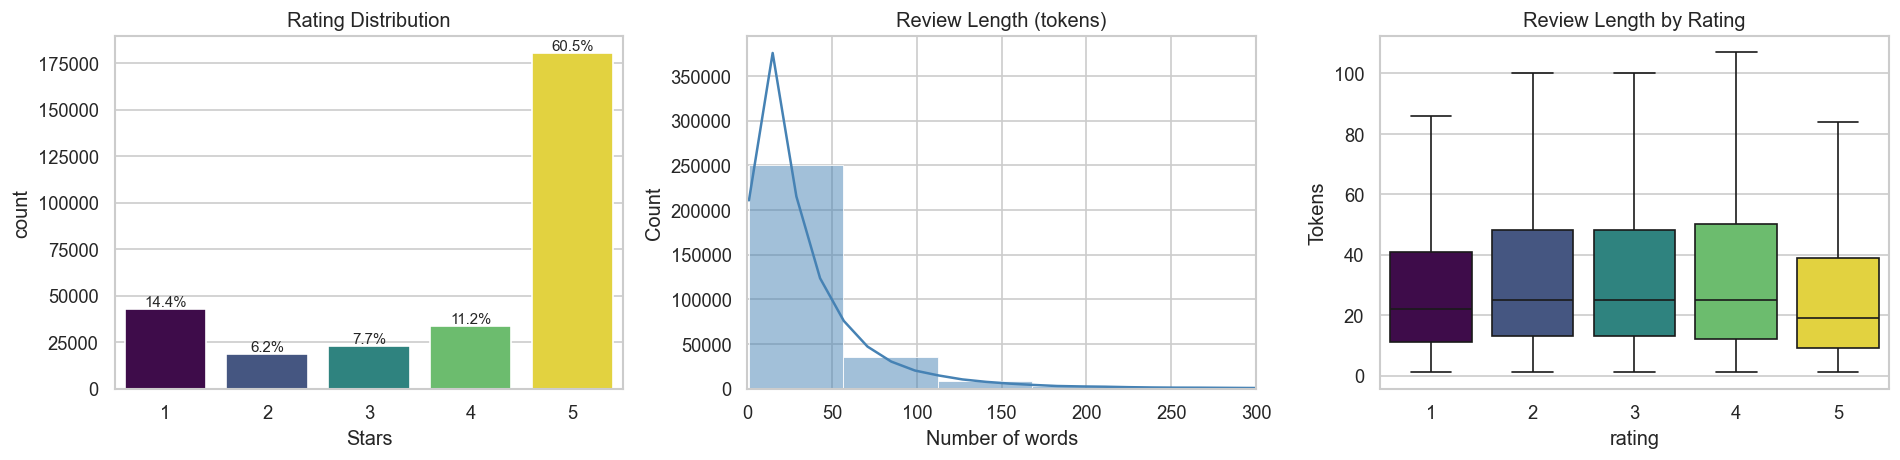

In [15]:
# Rating distribution
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

ax = sns.countplot(x="rating", data=df, ax=axes[0], palette="viridis",
                   hue="rating", legend=False)
axes[0].set_title("Rating Distribution")
axes[0].set_xlabel("Stars")

# Adding % labels on top of each bar
total = len(df)
for p in ax.patches:
    pct = f"{100 * p.get_height() / total:.1f}%"
    ax.annotate(pct, (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom", fontsize=9)

# Review length in tokens — capping at 300 to avoid outliers squashing the plot
sns.histplot(df["tok_len"], bins=50, kde=True, ax=axes[1], color="steelblue")
axes[1].set_title("Review Length (tokens)")
axes[1].set_xlabel("Number of words")
axes[1].set_xlim(0, 300)

# Review length by rating — hiding outliers to keep boxes readable
sns.boxplot(x="rating", y="tok_len", data=df, ax=axes[2], palette="viridis",
            showfliers=False, hue="rating", legend=False)
axes[2].set_title("Review Length by Rating")
axes[2].set_ylabel("Tokens")

plt.tight_layout()
plt.show()

## Top Words and N-grams

We extract the most frequent unigrams (single words) and bigrams (two-word phrases) across the entire corpus to get a first sense of the vocabulary and recurring themes in the reviews. English stopwords are removed, along with domain-specific terms (product, buy, amazon, etc.) that are too generic to carry meaningful signal, and they have been discovered after doing the plot several time. The bars are sorted by frequency in descending order.

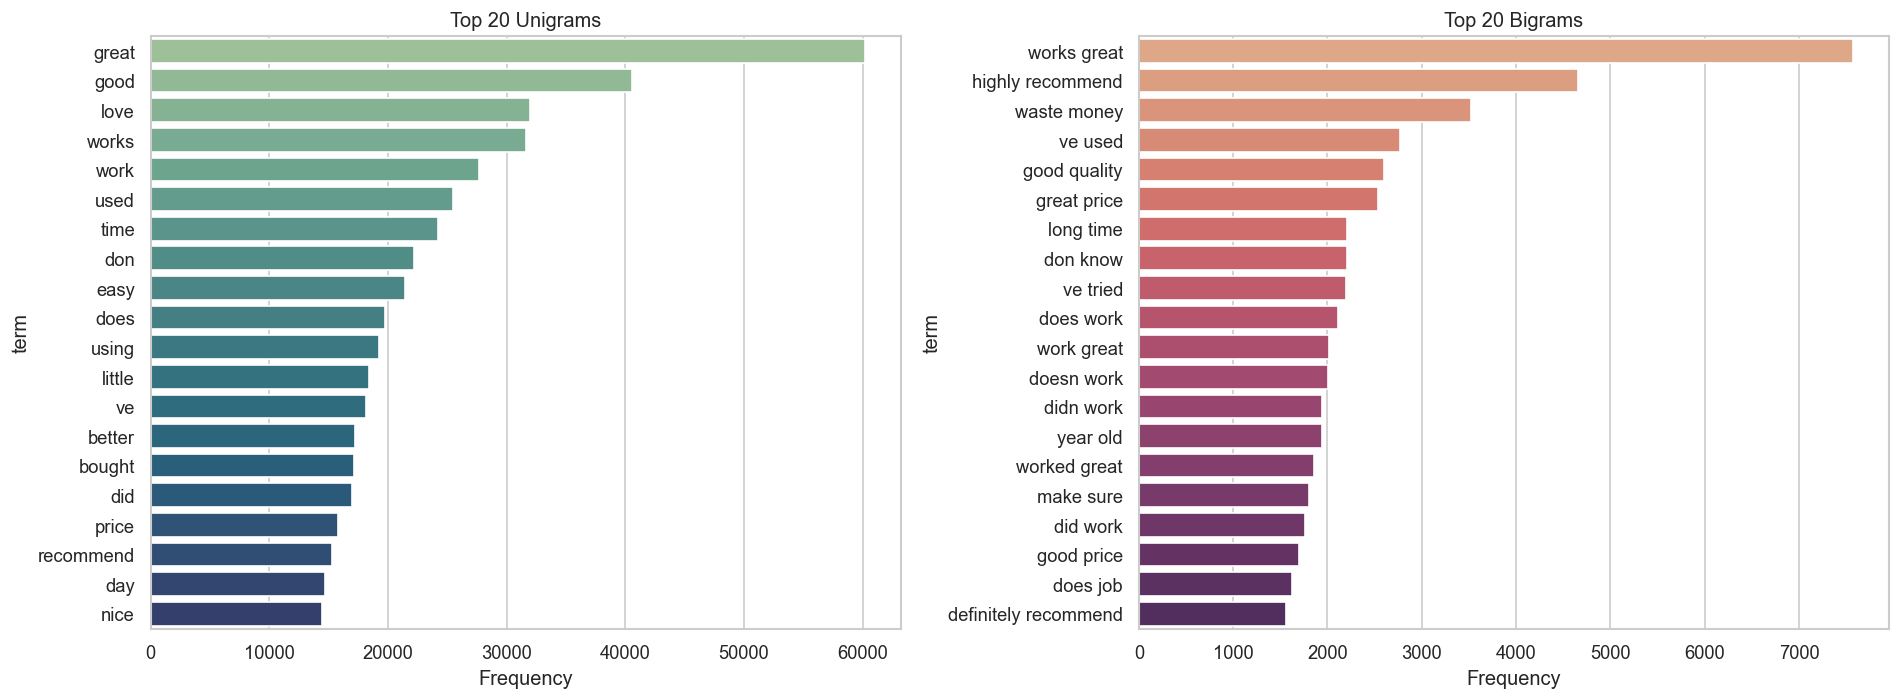

In [16]:
from sklearn.feature_extraction.text import CountVectorizer

# Filling NaN texts with empty string to avoid vectorizer errors
texts = df["text"].fillna("").astype(str)

# Domain-specific stopwords to add on top of sklearn's English list
DOMAIN_STOPWORDS = [
    "product", "buy", "amazon", "just", "really", "get", "one",
    "use", "like", "also", "even", "would", "could", "still"
]

# Top 20 unigrams (no stopwords)
vec_uni = CountVectorizer(stop_words=list(CountVectorizer(stop_words="english").get_stop_words()) + DOMAIN_STOPWORDS,
                          max_features=20)
X_uni = vec_uni.fit_transform(texts)
uni_freq = X_uni.sum(axis=0).A1
uni_terms = vec_uni.get_feature_names_out()

# Sort by frequency descending
order_uni = uni_freq.argsort()[::-1]
uni_terms, uni_freq = uni_terms[order_uni], uni_freq[order_uni]

# Top 20 bigrams (no stopwords)
vec_bi = CountVectorizer(ngram_range=(2, 2),
                         stop_words=list(CountVectorizer(stop_words="english").get_stop_words()) + DOMAIN_STOPWORDS,
                         max_features=20)
X_bi = vec_bi.fit_transform(texts)
bi_freq = X_bi.sum(axis=0).A1
bi_terms = vec_bi.get_feature_names_out()

# Sort by frequency descending
order_bi = bi_freq.argsort()[::-1]
bi_terms, bi_freq = bi_terms[order_bi], bi_freq[order_bi]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

df_uni = pd.DataFrame({"term": uni_terms, "freq": uni_freq})
df_bi  = pd.DataFrame({"term": bi_terms,  "freq": bi_freq})

sns.barplot(x="freq", y="term", data=df_uni, ax=axes[0], palette="crest",
            hue="term", legend=False)
axes[0].set_title("Top 20 Unigrams")
axes[0].set_xlabel("Frequency")

sns.barplot(x="freq", y="term", data=df_bi, ax=axes[1], palette="flare",
            hue="term", legend=False)
axes[1].set_title("Top 20 Bigrams")
axes[1].set_xlabel("Frequency")

plt.tight_layout()
plt.show()

## TF-IDF Top Terms per Rating Class

We split reviews into **positive (4-5 stars)** and **negative (1-2 stars)** and extract the most distinctive terms for each group using TF-IDF.

3-star reviews are deliberately excluded, neutral reviews tend to mix positive and negative vocabulary without adding useful discriminative signal.

A single TF-IDF model is fitted on the combined corpus (positive + negative) so that weights are on the same scale and the two groups are directly comparable.

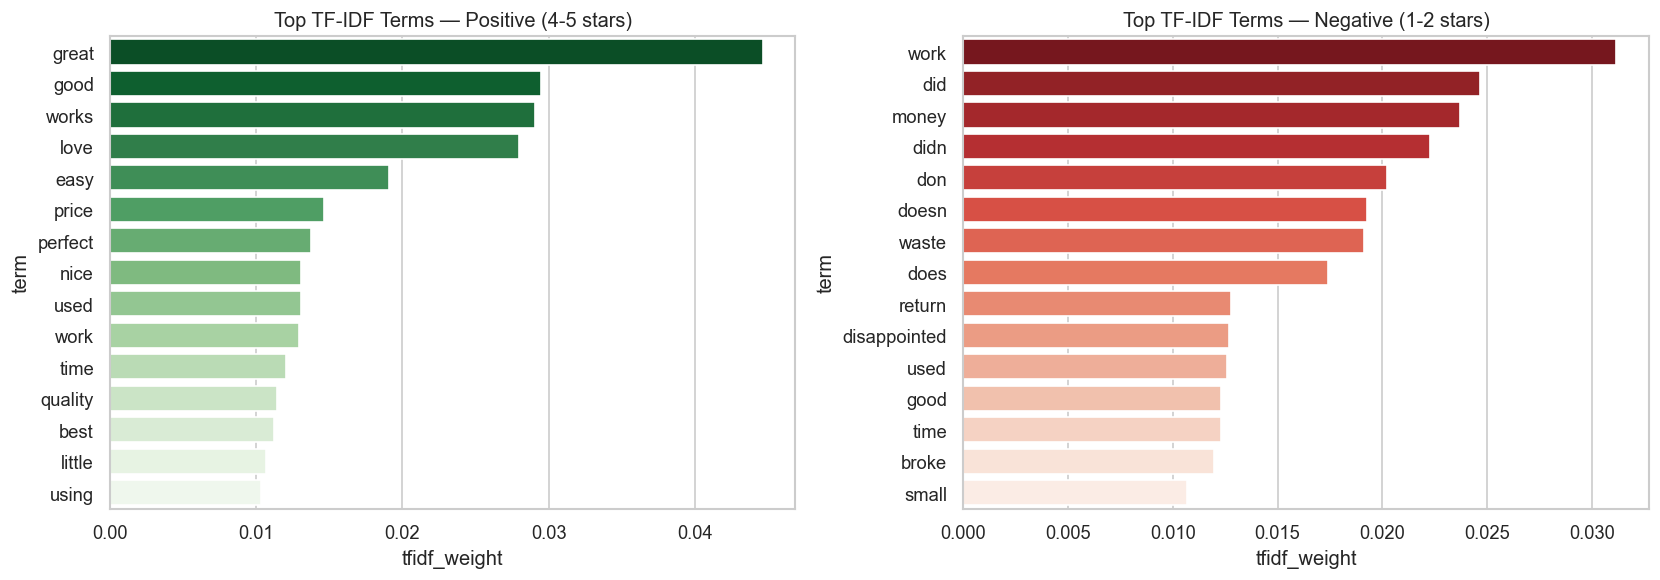

In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Splitting into positive and negative groups (3-star reviews excluded — neutral signal)
pos_texts = df[df["rating"] >= 4]["text"].fillna("").astype(str)
neg_texts = df[df["rating"] <= 2]["text"].fillna("").astype(str)
all_texts  = pd.concat([pos_texts, neg_texts])

# Same domain stopwords used in the n-gram analysis
DOMAIN_STOPWORDS = [
    "product", "buy", "amazon", "just", "really", "get", "one",
    "use", "like", "also", "even", "would", "could", "still"
]
combined_stopwords = list(CountVectorizer(stop_words="english").get_stop_words()) + DOMAIN_STOPWORDS

# Fit a SINGLE TF-IDF on the full corpus so weights are on the same scale
tfidf = TfidfVectorizer(stop_words=combined_stopwords, max_features=5000, sublinear_tf=True)
tfidf.fit(all_texts)

def top_tfidf_terms(texts, n=15):
    """Transform texts with the shared TF-IDF and return top n terms by mean weight."""
    X = tfidf.transform(texts)
    mean_weights = X.mean(axis=0).A1
    top_idx = mean_weights.argsort()[-n:][::-1]
    terms = tfidf.get_feature_names_out()[top_idx]
    weights = mean_weights[top_idx]
    return pd.DataFrame({"term": terms, "tfidf_weight": weights})

top_pos = top_tfidf_terms(pos_texts)
top_neg = top_tfidf_terms(neg_texts)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(x="tfidf_weight", y="term", data=top_pos, ax=axes[0], palette="Greens_r",
            hue="term", legend=False)
axes[0].set_title("Top TF-IDF Terms — Positive (4-5 stars)")

sns.barplot(x="tfidf_weight", y="term", data=top_neg, ax=axes[1], palette="Reds_r",
            hue="term", legend=False)
axes[1].set_title("Top TF-IDF Terms — Negative (1-2 stars)")

plt.tight_layout()
plt.show()

### Limitation: Negation Blindness

Some terms in the negative group don't make much sense at first glance, "good", "work", does show up in both positive and negative reviews. The reason is that bag-of-words has no notion of negation: "doesn't work" and "works great" both contribute the word work to the count.

Using bigrams should help since doesn't work and works great become two different features.

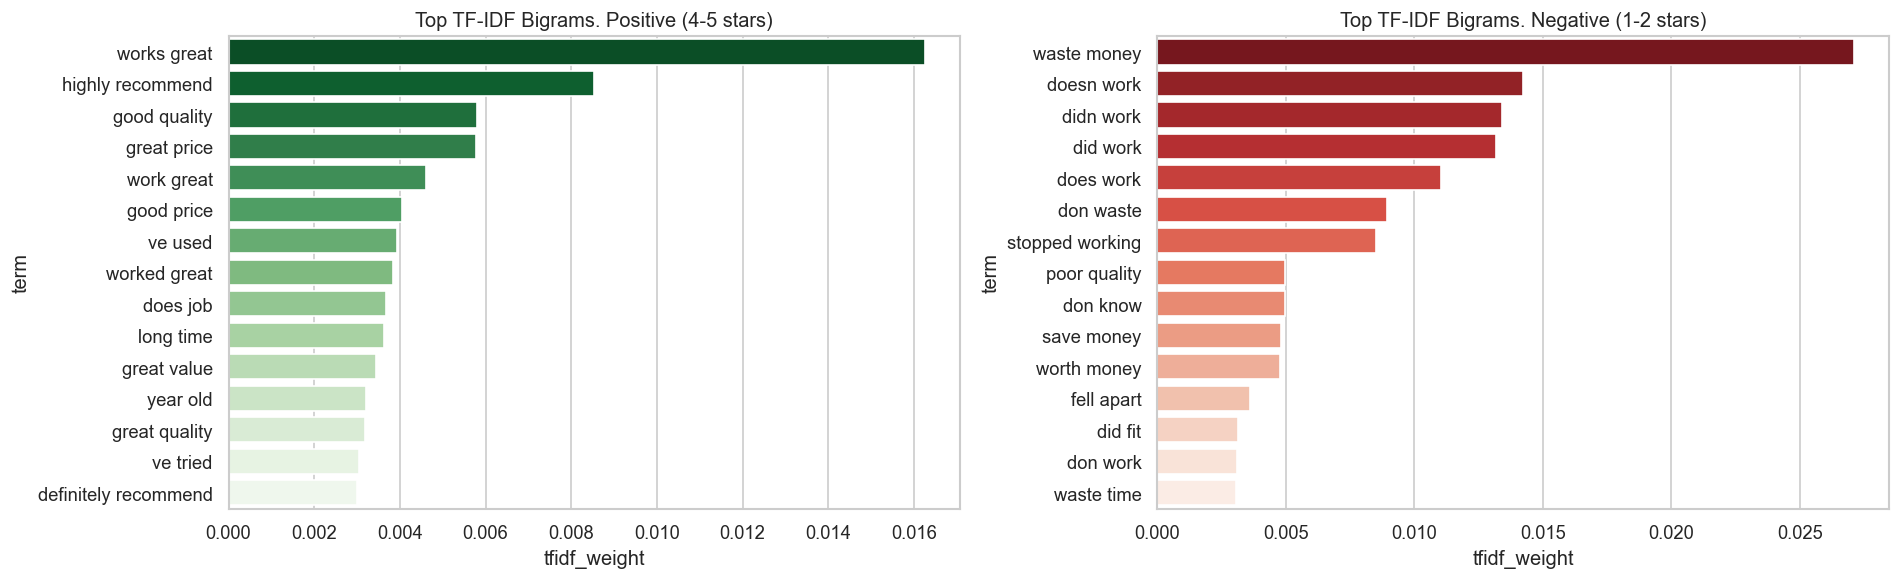

In [18]:
# TF-IDF with bigrams
tfidf_bi = TfidfVectorizer(
    stop_words=combined_stopwords,
    max_features=5000,
    sublinear_tf=True,
    ngram_range=(2, 2)   # bigrams only
)
tfidf_bi.fit(all_texts)

def top_tfidf_bigrams(texts, n=15):
    X = tfidf_bi.transform(texts)
    mean_weights = X.mean(axis=0).A1
    top_idx = mean_weights.argsort()[-n:][::-1]
    terms = tfidf_bi.get_feature_names_out()[top_idx]
    weights = mean_weights[top_idx]
    return pd.DataFrame({"term": terms, "tfidf_weight": weights})

top_pos_bi = top_tfidf_bigrams(pos_texts)
top_neg_bi = top_tfidf_bigrams(neg_texts)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(x="tfidf_weight", y="term", data=top_pos_bi, ax=axes[0], palette="Greens_r",
            hue="term", legend=False)
axes[0].set_title("Top TF-IDF Bigrams. Positive (4-5 stars)")

sns.barplot(x="tfidf_weight", y="term", data=top_neg_bi, ax=axes[1], palette="Reds_r",
            hue="term", legend=False)
axes[1].set_title("Top TF-IDF Bigrams. Negative (1-2 stars)")

plt.tight_layout()
plt.show()

## Sentiment Polarity Check

Quick polarity scoring with TextBlob to compare automated sentiment against the user-given star rating.

Note: 2-star reviews show a surprisingly positive median polarity. This is likely because reviews like *"great product but stopped working after a week"* have enough positive language to pull the score up, even though the overall experience was negative.

Average polarity by star rating:
rating
1   -0.046646
2    0.049077
3    0.123909
4    0.233602
5    0.347260
Name: polarity, dtype: float64

Sentiment-rating mismatch rate: 4.07%


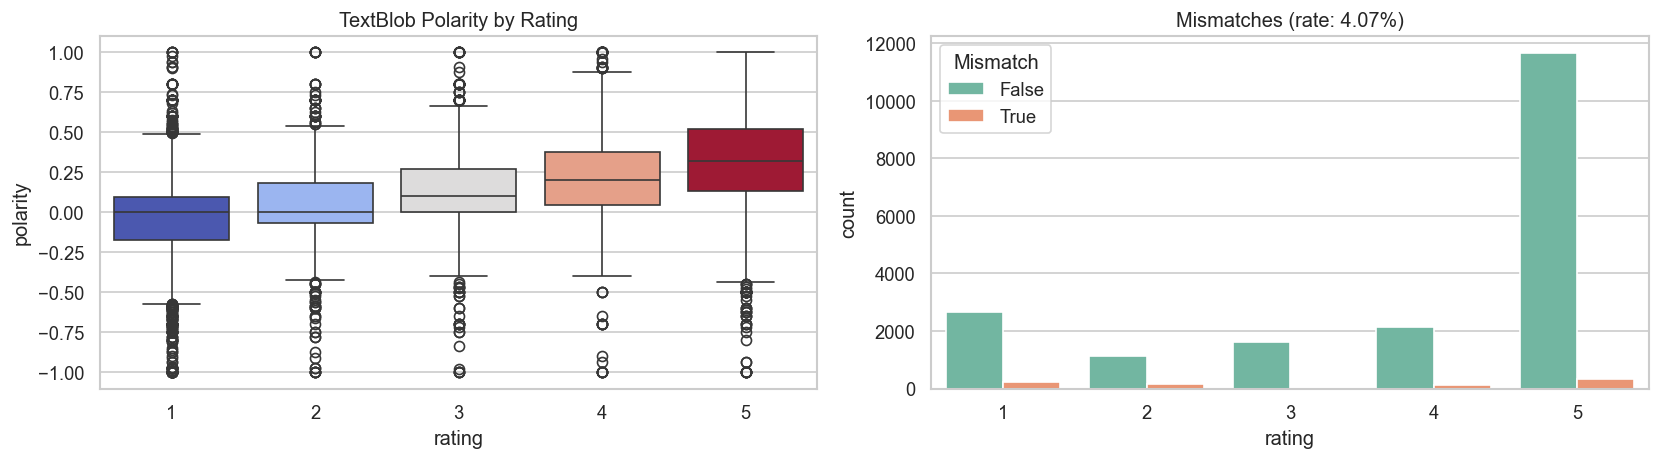

In [19]:
from textblob import TextBlob

# Computing polarity on a sample to keep it fast
POLARITY_SAMPLE = min(20_000, len(df))
df_pol = df.sample(POLARITY_SAMPLE, random_state=42).copy()
df_pol["polarity"] = df_pol["text"].fillna("").astype(str).apply(lambda t: TextBlob(t).sentiment.polarity)

# Average polarity per star rating
pol_by_rating = df_pol.groupby("rating")["polarity"].mean()
print("Average polarity by star rating:")
print(pol_by_rating)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.boxplot(x="rating", y="polarity", data=df_pol, ax=axes[0],
            palette="coolwarm", hue="rating", legend=False)
axes[0].set_title("TextBlob Polarity by Rating")

# Mismatch analysis: low rating but high polarity (and vice versa)
df_pol["mismatch"] = (
    ((df_pol["rating"] <= 2) & (df_pol["polarity"] > 0.3)) |
    ((df_pol["rating"] >= 4) & (df_pol["polarity"] < -0.1))
)
mismatch_rate = df_pol["mismatch"].mean()
print(f"\nSentiment-rating mismatch rate: {mismatch_rate:.2%}")

sns.countplot(x="rating", hue="mismatch", data=df_pol, ax=axes[1], palette="Set2")
axes[1].set_title(f"Mismatches (rate: {mismatch_rate:.2%})")
axes[1].legend(title="Mismatch")

plt.tight_layout()
plt.show()

## Quality & Duplicate Check

Final data quality pass: we look for duplicate reviews, empty texts and confirm no leakage exists in the cleaned dataset.

In [20]:
# Final quality verification, all checks should show 0 
dup_text = df.duplicated(subset=["text"]).sum()
dup_user_product = df.duplicated(subset=["user_id", "parent_asin"]).sum()
empty_text = (df["text"].astype(str).str.strip().str.len() == 0).sum()

print(f"Duplicate review texts:          {dup_text:,}")
print(f"Duplicate user+product combos:   {dup_user_product:,}")
print(f"Empty text fields:               {empty_text:,}")

# Missing values in key columns
key_cols = ["rating", "text", "parent_asin", "product_title", "brand", "price"]
missing_pct = df[key_cols].isna().mean().sort_values(ascending=False)
print("\nMissing % in key columns:")
print(missing_pct)
# Note: price is missing ~57%

# Rating sanity check
print(f"\nRating range: {df['rating'].min()} \u2013 {df['rating'].max()}")
print(f"Rating value counts:\n{df['rating'].value_counts().sort_index()}")

Duplicate review texts:          0
Duplicate user+product combos:   0
Empty text fields:               0

Missing % in key columns:
price            0.578301
brand            0.297951
product_title    0.000868
text             0.000003
rating           0.000000
parent_asin      0.000000
dtype: float64

Rating range: 1 – 5
Rating value counts:
rating
1     42883
2     18549
3     23015
4     33572
5    180507
Name: count, dtype: int64
